In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *
from modules.index.visualisation import plot_indices_with_returns

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (104, 152)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find Signed EPI variants
signed_epi_variants = find_index_variants(df.columns, 'epi_signed')
ASSET_COLS = [
    'r_btc', 'r_gold', 'r_spx', 
    'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 
    'r_aapl'
]
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nSigned EPI variants found: {len(signed_epi_variants)}")
for i, var in enumerate(signed_epi_variants, 1):
    print(f"  {i}. {var}")
print(f"\nAssets: {ASSET_COLS}")


Signed EPI variants found: 4
  1. epi_signed
  2. epi_signed_engweighted
  3. epi_signed_topicweighted
  4. epi_signed_engweighted_topicweighted

Assets: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']


## Descriptive Statistics


Descriptive Statistics

Signed EPI Variants


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
epi_signed,104.0,-0.025354,0.054078,-0.226484,-0.036660,-0.025010,-1.294032e-02,0.228975,0.682739,9.015962,0.0,0.000000
epi_signed_engweighted,104.0,-0.024993,0.052876,-0.226484,-0.036697,-0.024047,-1.259483e-02,0.222858,0.598183,9.414747,0.0,0.000000
epi_signed_engweighted_topicweighted,104.0,-0.005821,0.015958,-0.069945,-0.013074,-0.002176,1.347500e-08,0.061480,-0.008547,4.765379,0.0,6.730769
epi_signed_topicweighted,104.0,-0.020665,0.029322,-0.072610,-0.035910,-0.022783,-9.206360e-03,0.121523,2.018660,7.746403,0.0,4.807692



Correlation between variants:


,epi_signed,epi_signed_engweighted,epi_signed_topicweighted,epi_signed_engweighted_topicweighted
epi_signed,1.000000,0.994087,0.252020,0.368240
epi_signed_engweighted,0.994087,1.000000,0.233219,0.379693
epi_signed_topicweighted,0.252020,0.233219,1.000000,0.274219
epi_signed_engweighted_topicweighted,0.368240,0.379693,0.274219,1.000000


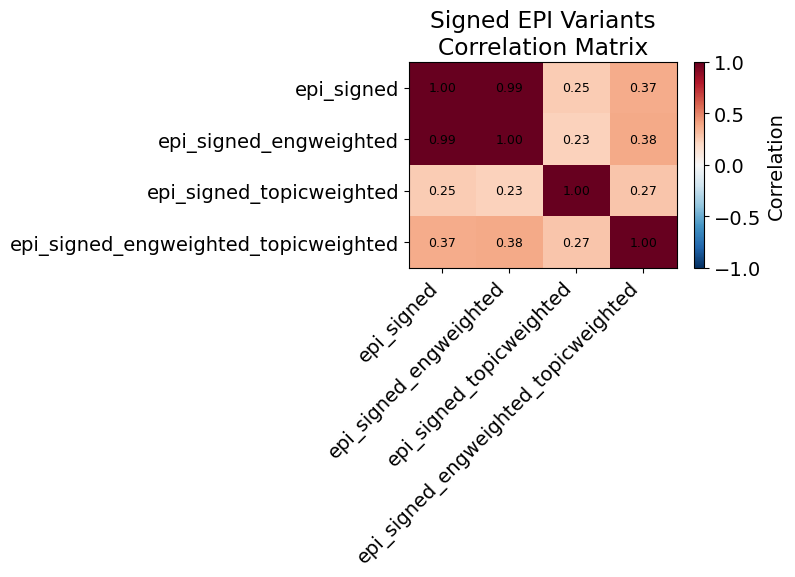

In [5]:
print("\n" + "="*70)
print("Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, signed_epi_variants, 'Signed EPI Variants')

## Time Series Visualization


Time Series Visualization


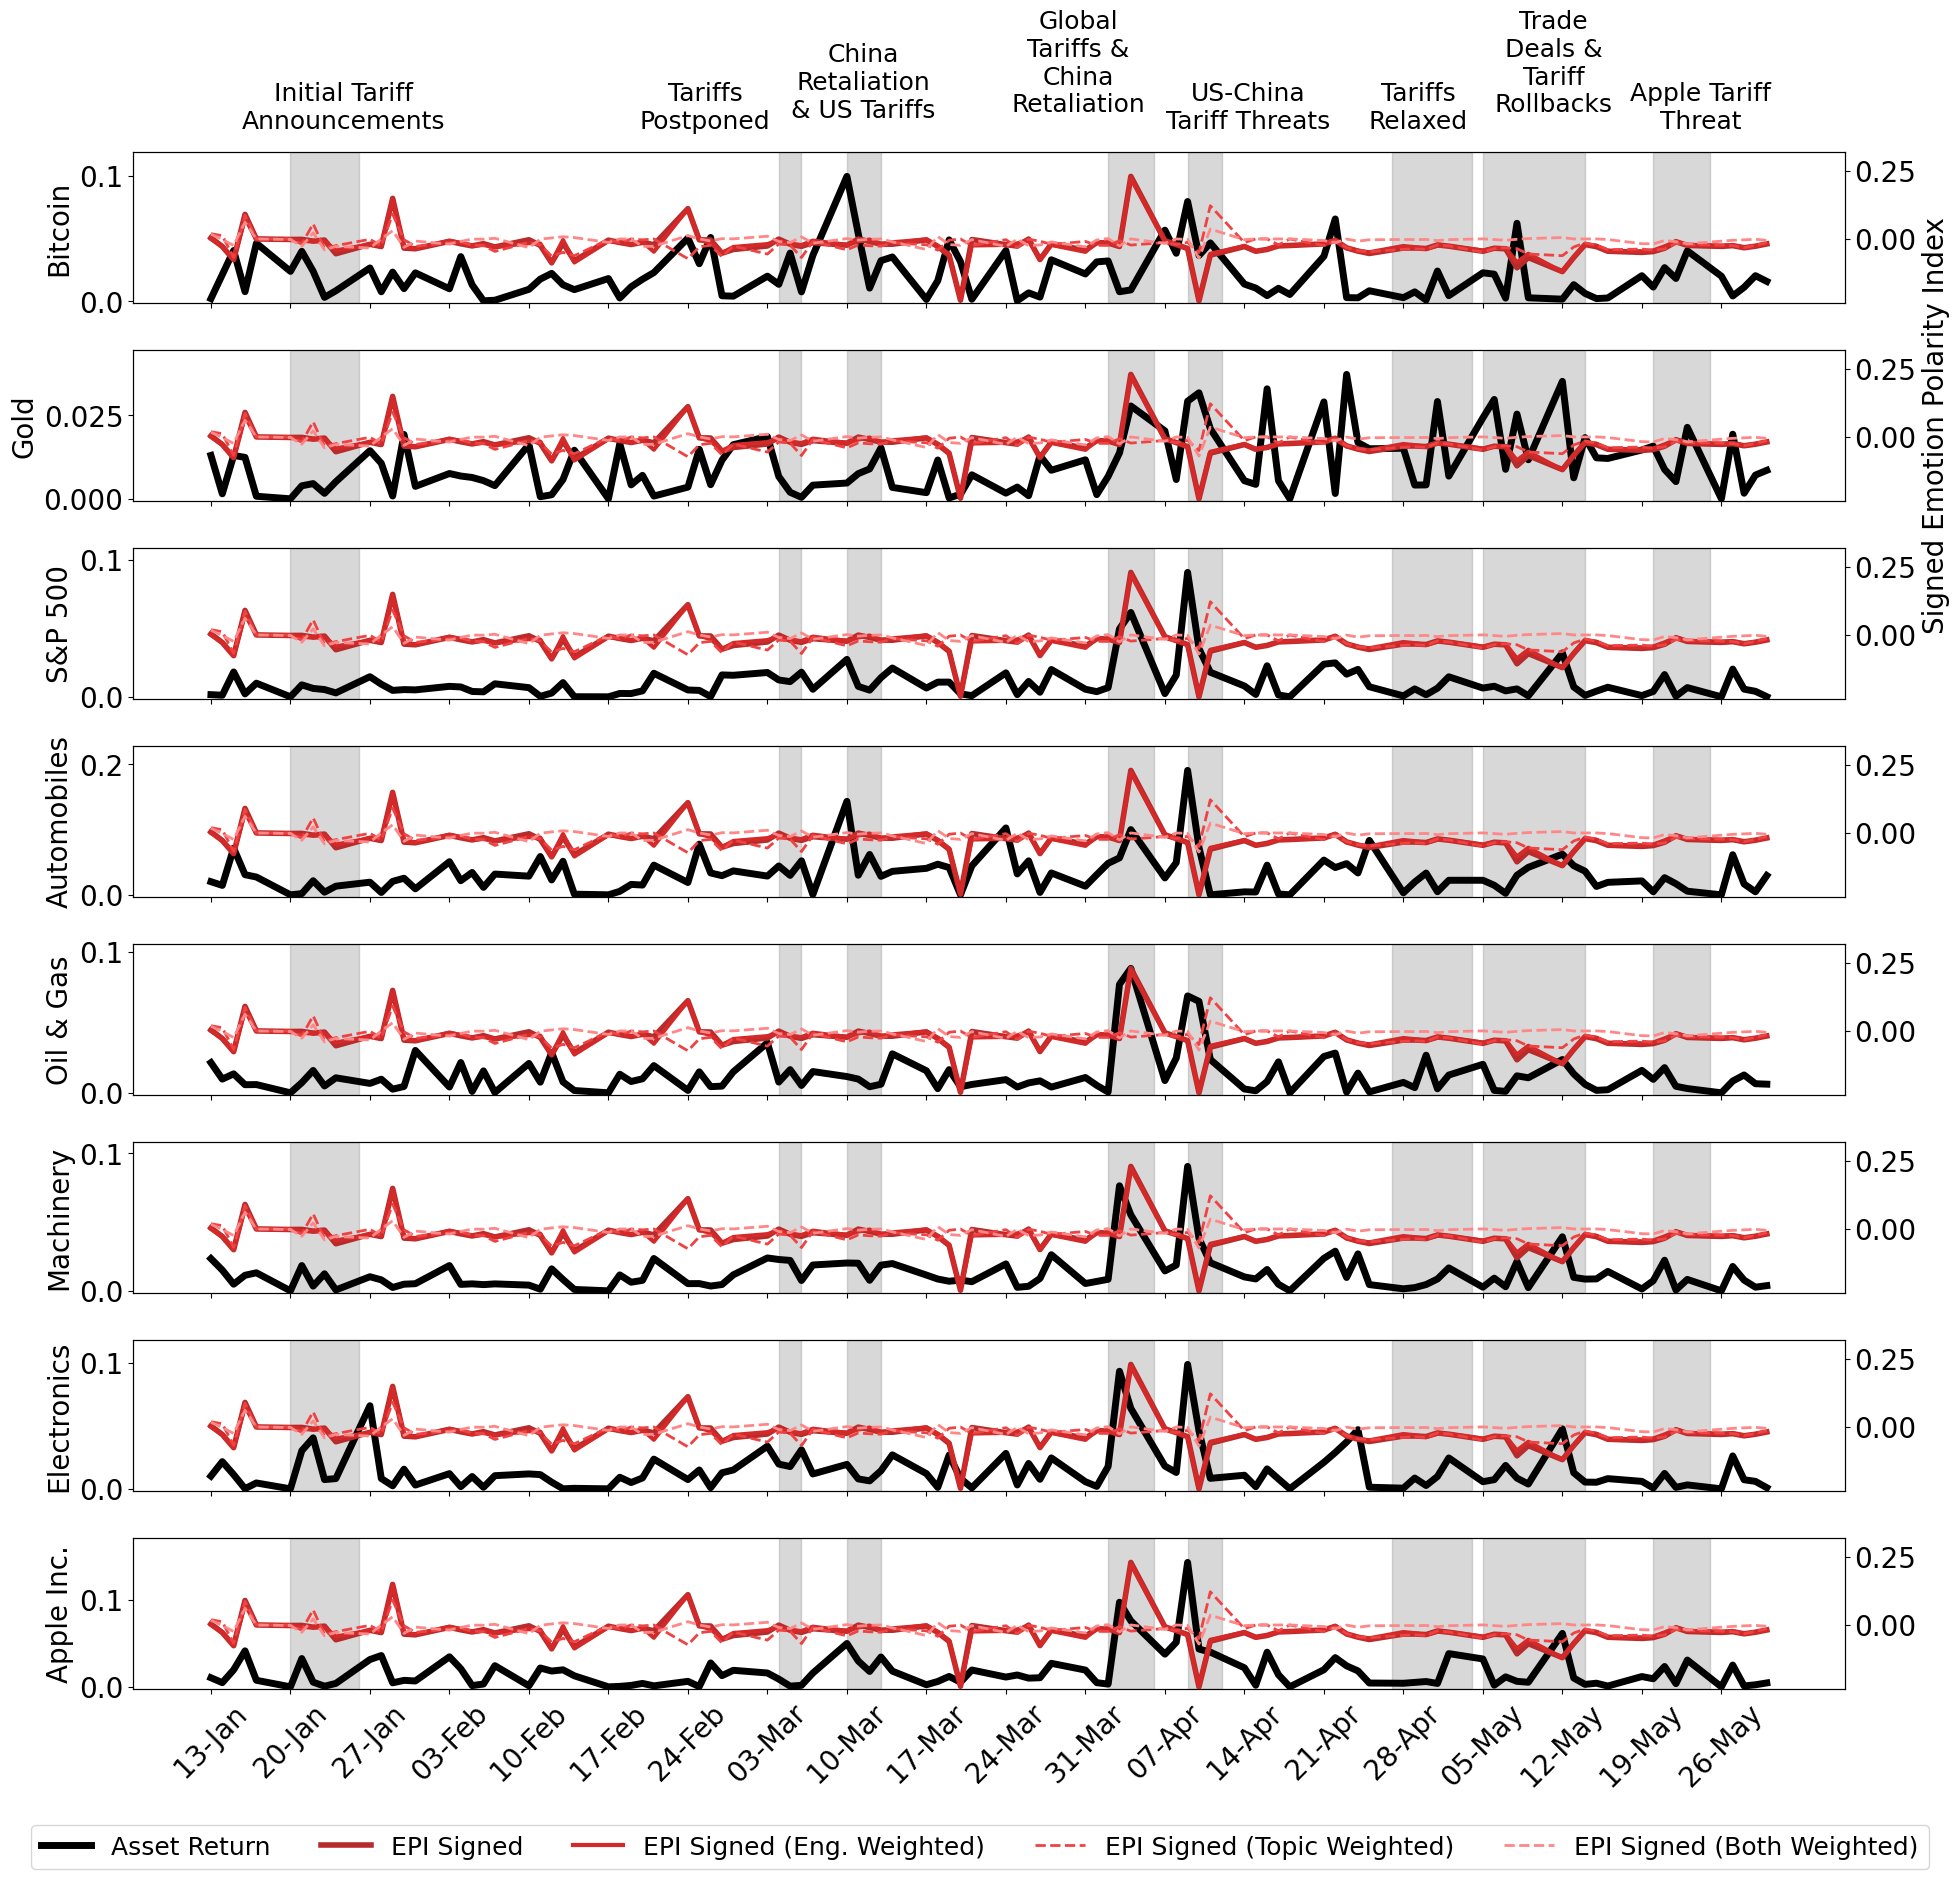

In [6]:
print("\n" + "="*70)
print("Time Series Visualization")
print("="*70)
plot_indices_with_returns(df, index_type='epi_signed', include_variants=signed_epi_variants, add_events=True)

## Rolling Correlations with Assets


Rolling Correlations with Assets


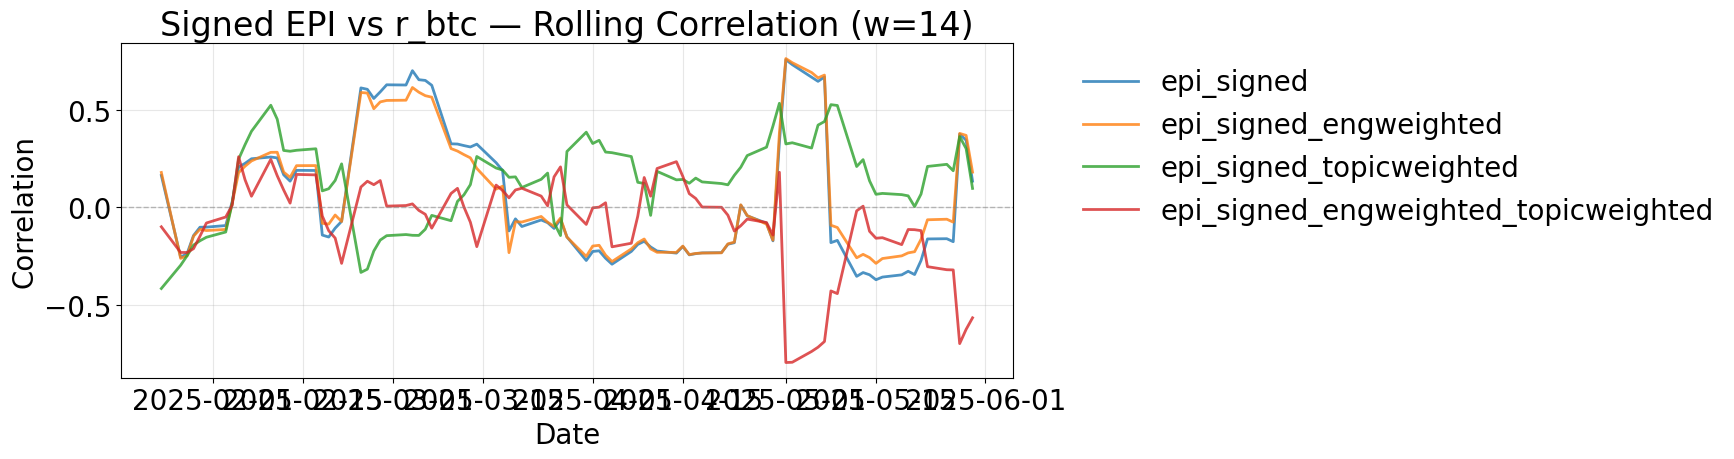

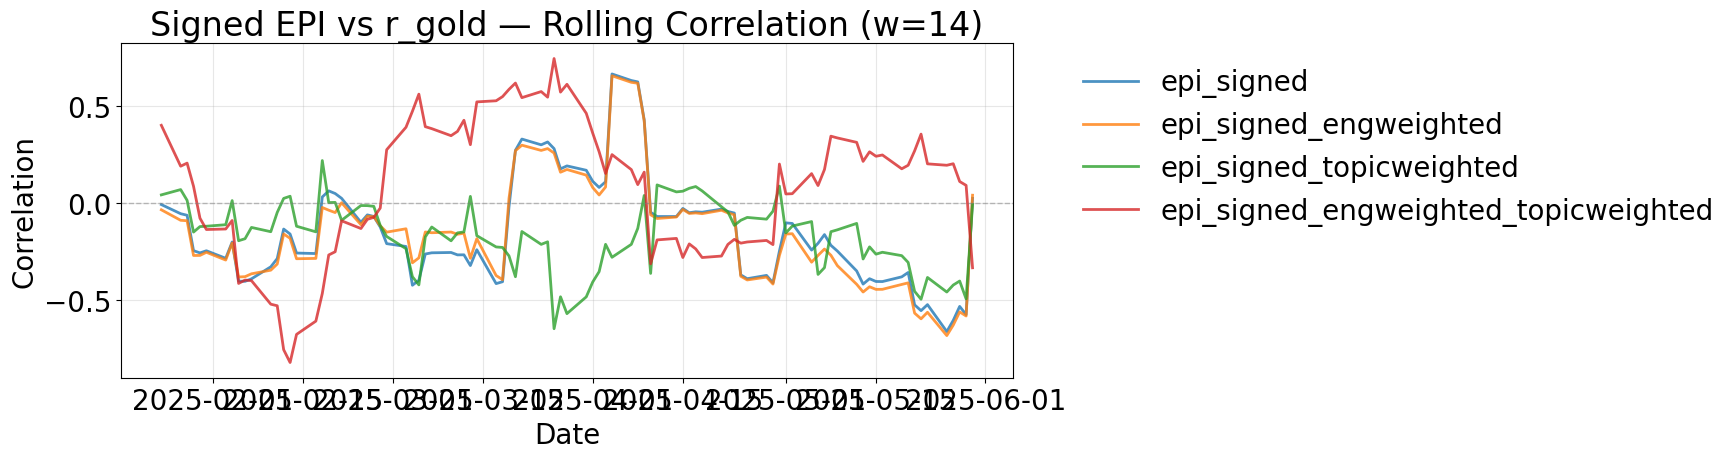

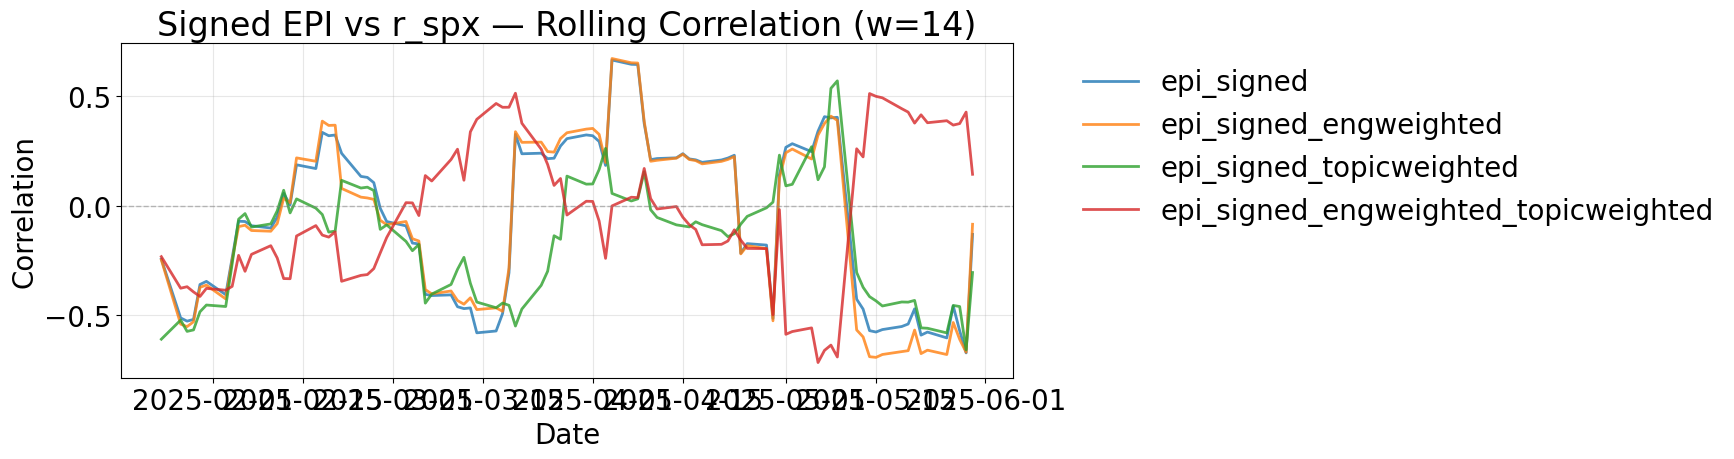

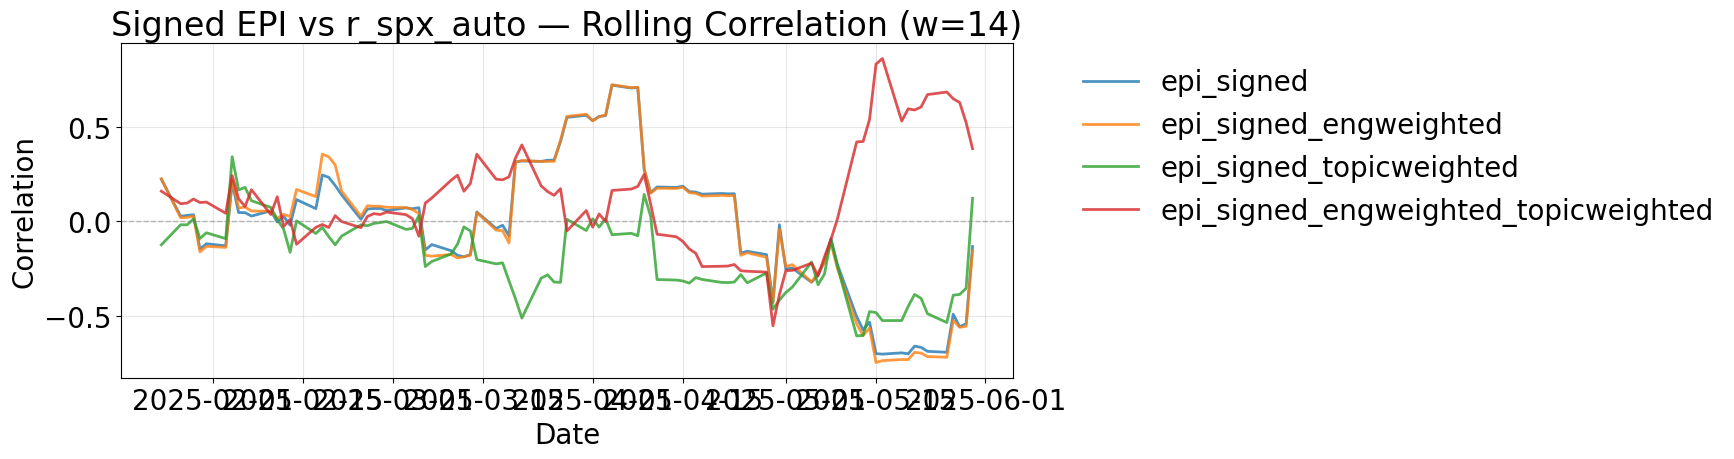

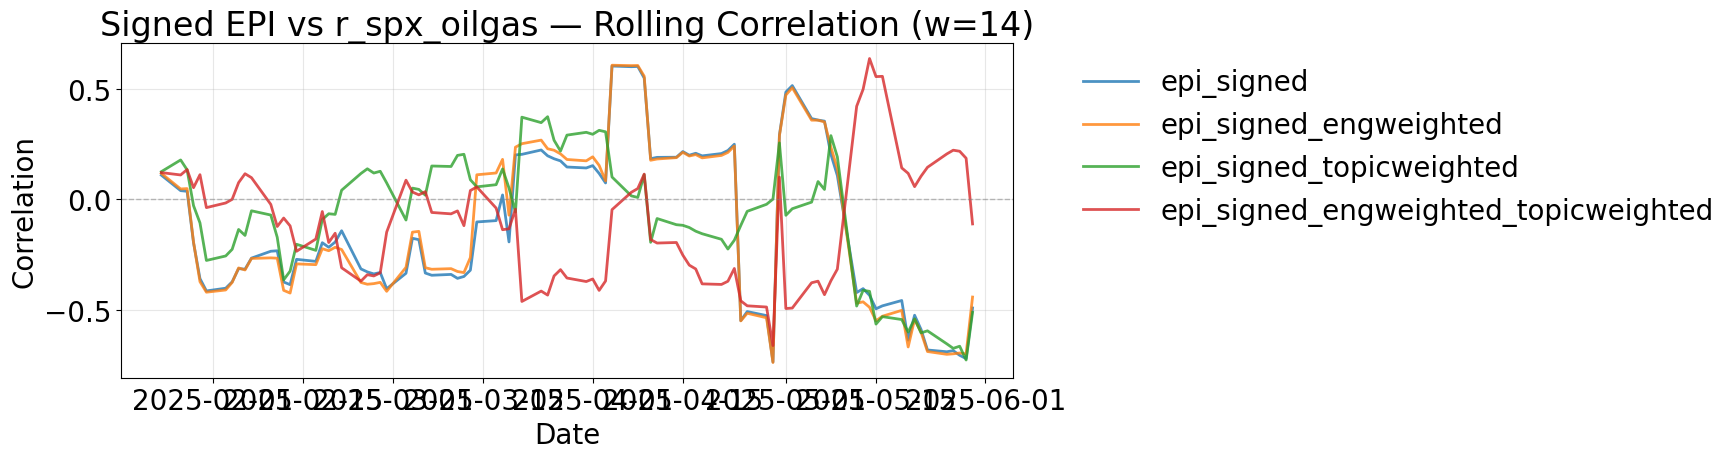

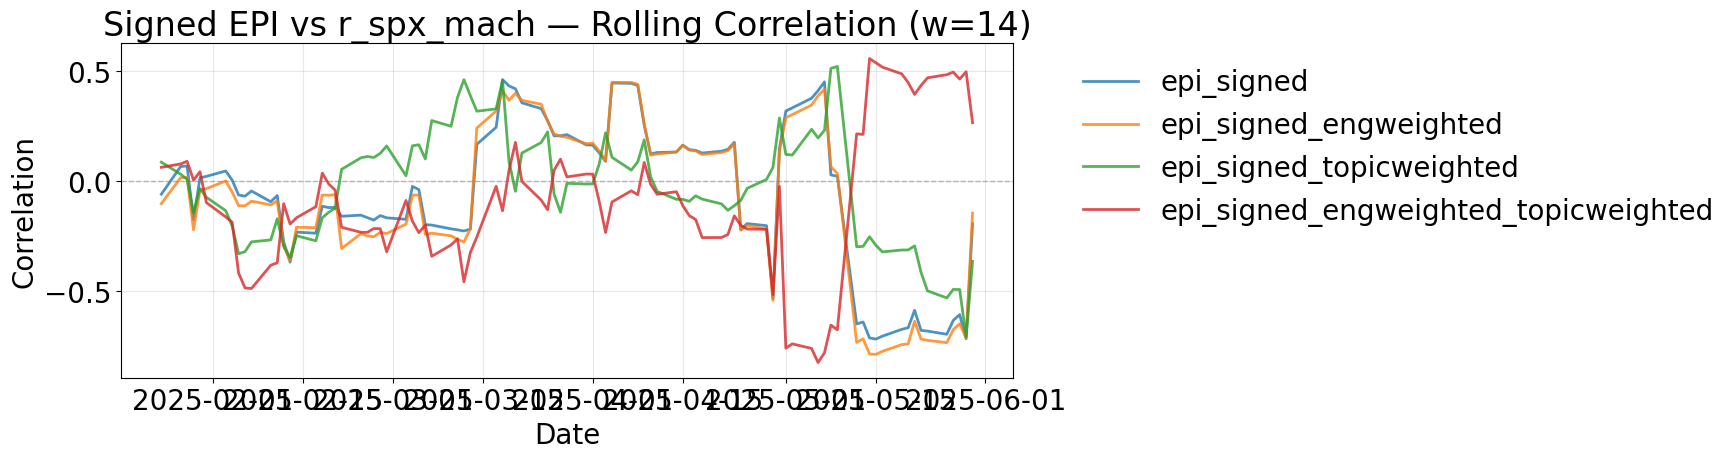

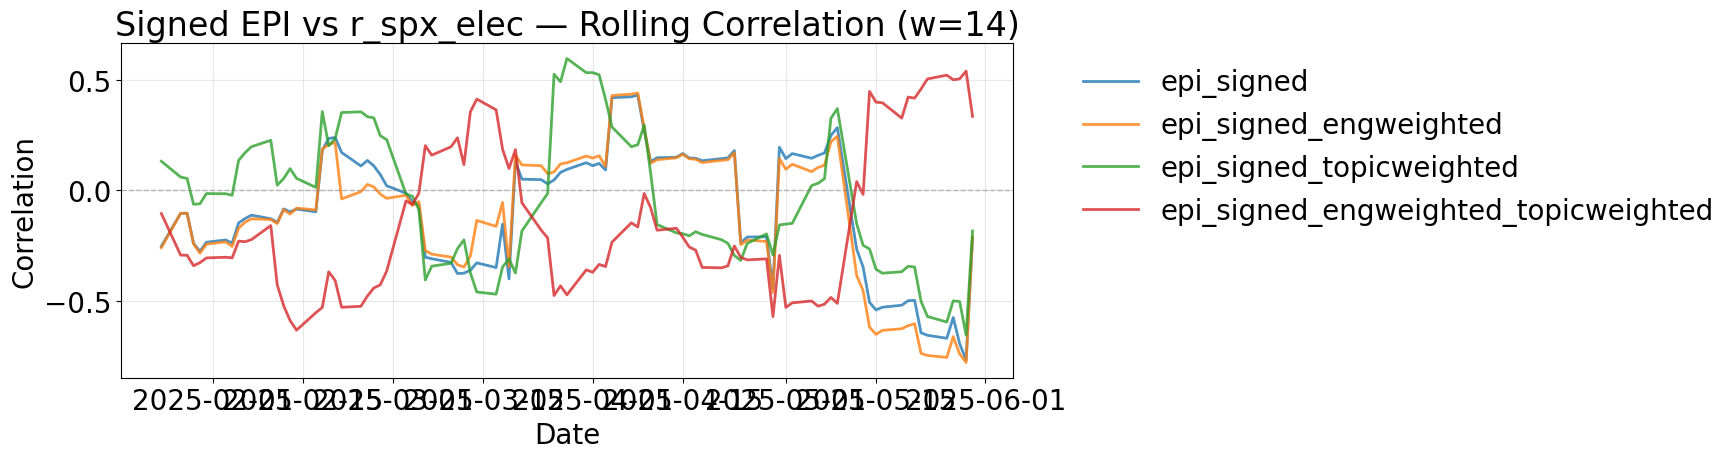

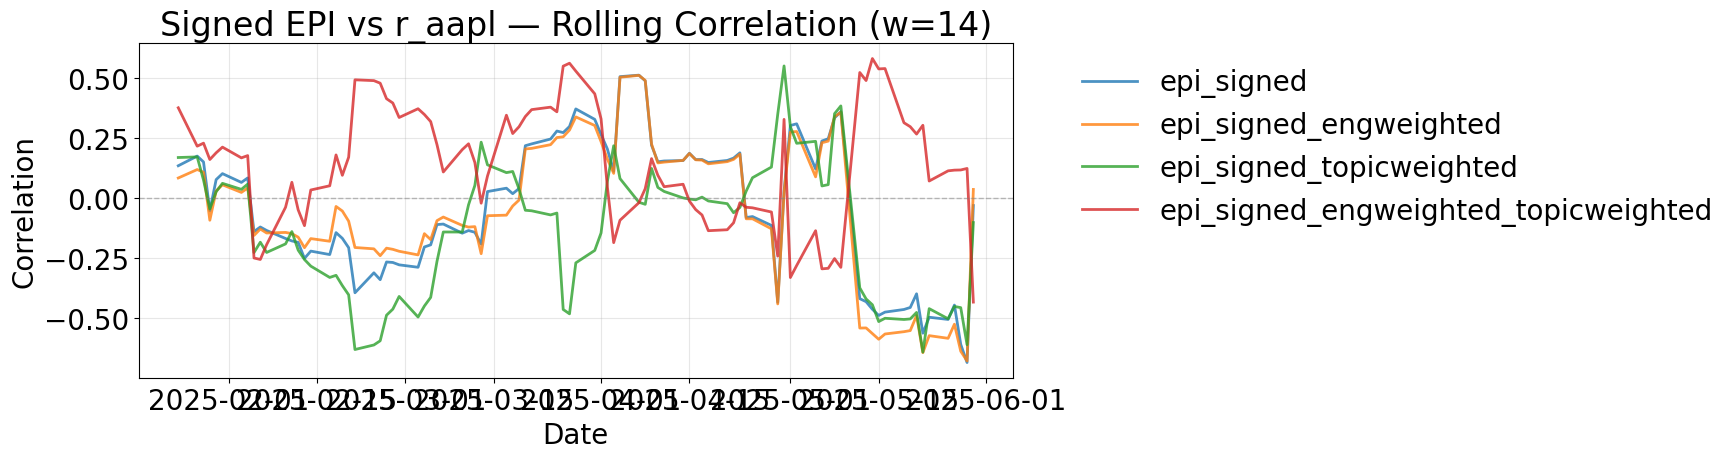

In [7]:
print("\n" + "="*70)
print("Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, signed_epi_variants, ASSET_COLS, 'Signed EPI', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if Signed EPI variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


Granger Causality Tests

GRANGER CAUSALITY TESTS: EPI Variants
Running 32 Granger causality tests...
  Index → Asset causality
  Max lag: 10, Max lead: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  LAG tests - Significant relationships (corrected α=0.05): 6 of 32
  LAG tests - Uncorrected significant (α=0.05): 6
  LEAD tests - Significant relationships (corrected α=0.05): 10 of 32
  LEAD tests - Uncorrected significant (α=0.05): 10

LAG RESULTS: X(t-k) → Y(t)

P-values (at optimal lag):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
epi_signed,0.000313,0.060564,0.656288,0.001132,0.868089,0.000680,0.540741,0.350533
epi_signed_engweighted,0.000603,0.085451,0.792616,0.001336,0.902606,0.000863,0.586746,0.392649
epi_signed_engweighted_topicweighted,0.219757,0.881189,0.762283,0.793832,0.851741,0.616017,0.605895,0.766038
epi_signed_topicweighted,0.844504,0.701051,0.313481,0.612440,0.676862,0.804087,0.967831,0.669924



Corrected p-values (fdr_bh):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
epi_signed,0.006908,0.276866,0.931722,0.007128,0.931722,0.006908,0.931722,0.931722
epi_signed_engweighted,0.006908,0.341802,0.931722,0.007128,0.931722,0.006908,0.931722,0.931722
epi_signed_engweighted_topicweighted,0.781358,0.931722,0.931722,0.931722,0.931722,0.931722,0.931722,0.931722
epi_signed_topicweighted,0.931722,0.931722,0.931722,0.931722,0.931722,0.931722,0.967831,0.931722



Significant relationships (α=0.05, corrected):


...

asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
epi_signed,0.000027,0.212226,0.347006,0.000053,0.008658,0.000118,0.000095,0.206775
epi_signed_engweighted,0.000068,0.207411,0.374006,0.000070,0.008681,0.000172,0.000130,0.214555
epi_signed_engweighted_topicweighted,0.456234,0.544859,0.779347,0.568457,0.348902,0.130241,0.416155,0.395043
epi_signed_topicweighted,0.660894,0.625480,0.184331,0.800948,0.593829,0.672777,0.775129,0.677229



Corrected p-values (fdr_bh):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
epi_signed,0.000557,0.429110,0.620271,0.000557,0.027778,0.000596,0.000596,0.429110
epi_signed_engweighted,0.000557,0.429110,0.629905,0.000557,0.027778,0.000689,0.000596,0.429110
epi_signed_engweighted_topicweighted,0.663614,0.747287,0.800948,0.747287,0.620271,0.378883,0.634141,0.632069
epi_signed_topicweighted,0.747287,0.747287,0.429110,0.800948,0.747287,0.747287,0.800948,0.747287



Significant relationships (α=0.05, corrected):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
epi_signed,1,0,0,1,1,1,1,0
epi_signed_engweighted,1,0,0,1,1,1,1,0
epi_signed_engweighted_topicweighted,0,0,0,0,0,0,0,0
epi_signed_topicweighted,0,0,0,0,0,0,0,0


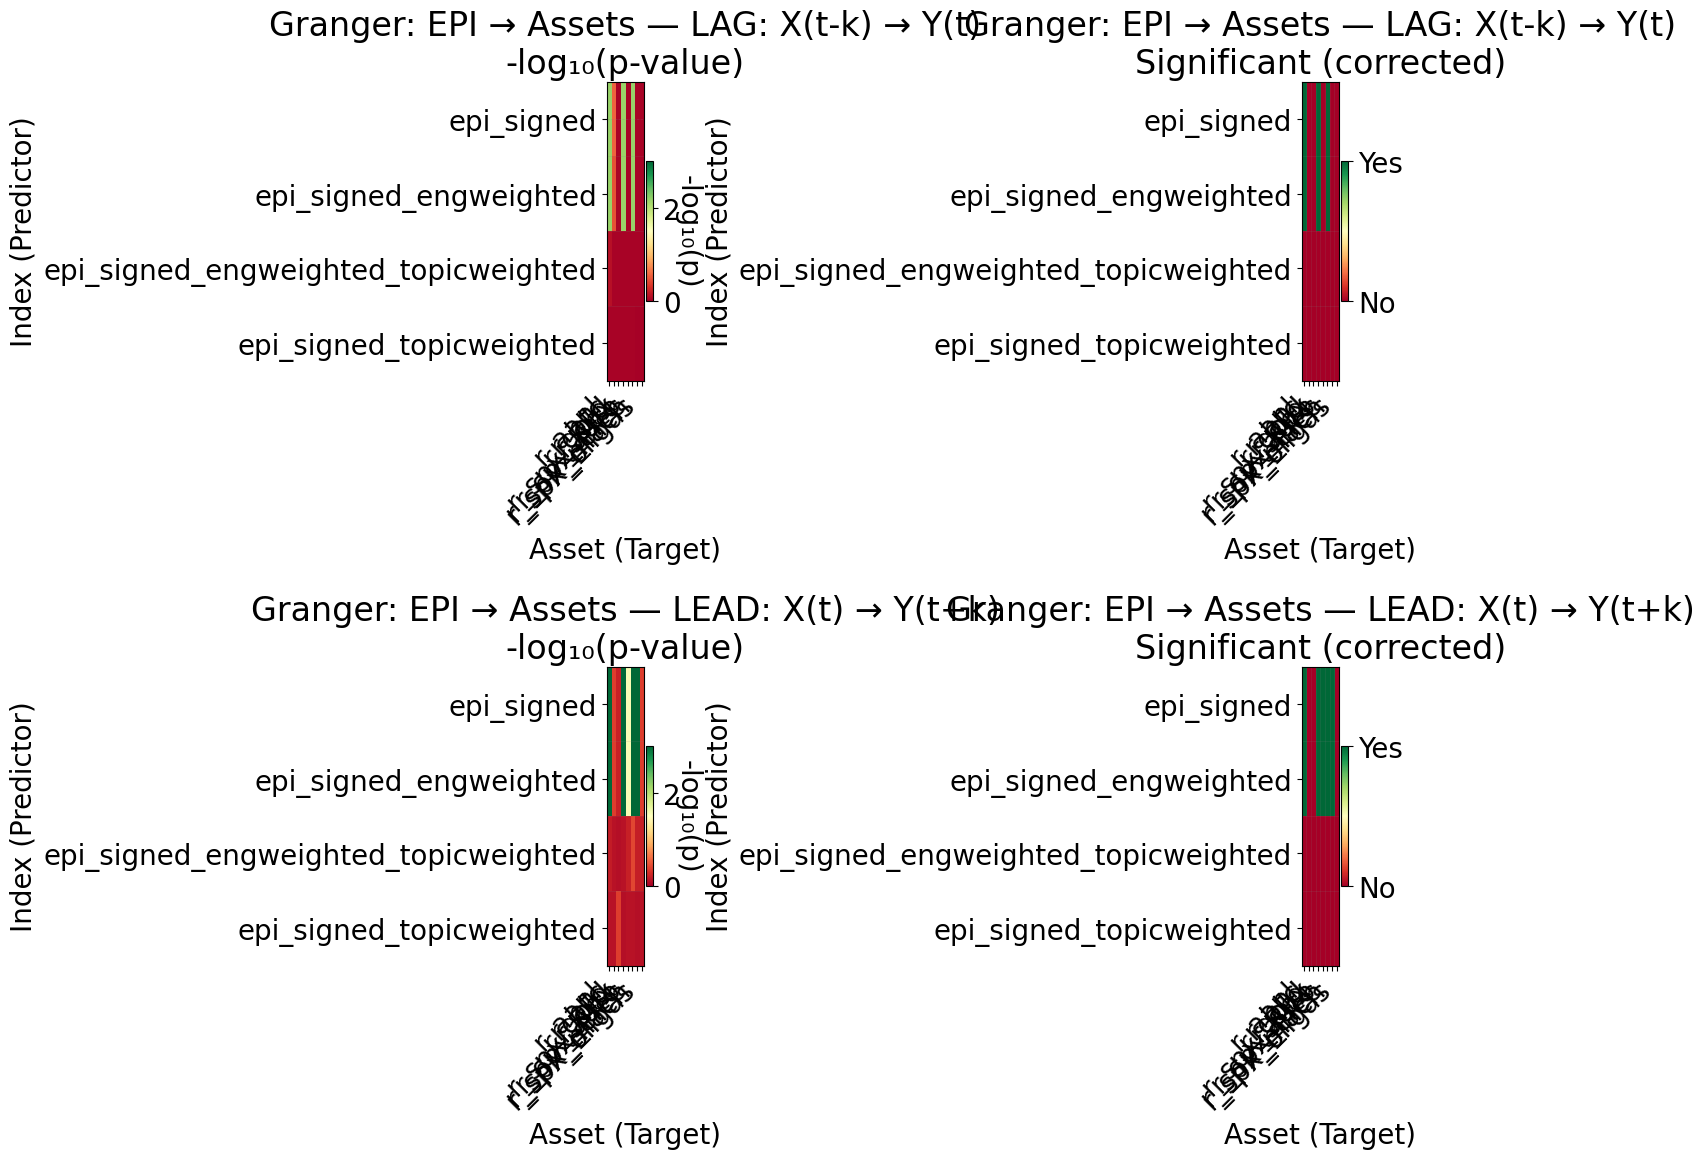

In [8]:
print("\n" + "="*70)
print("Granger Causality Tests")
print("="*70)

(pval_mat, pval_corrected, sig_mat, 
 lead_pval_mat, lead_pval_corrected, lead_sig_mat) = granger_comparison_variants(
    df, signed_epi_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [9]:
# Variant performance summary
print("\n" + "="*70)
print("Performance Summary")
print("="*70)
performance = summarize_variant_performance(
    pval_mat, sig_mat, 
    lead_pval_mat, lead_sig_mat, 
    signed_epi_variants
)


Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant_lags,mean_pvalue_lags,min_pvalue_lags,n_significant_leads,mean_pvalue_leads,min_pvalue_leads,total_significant
0,epi_signed,3,0.309793,0.000313,5,0.096870,0.000027,8
1,epi_signed_engweighted,3,0.345359,0.000603,5,0.100637,0.000068,8
2,epi_signed_topicweighted,0,0.698772,0.313481,0,0.623827,0.184331,0
3,epi_signed_engweighted_topicweighted,0,0.687094,0.219757,0,0.454905,0.130241,0


In [10]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [11]:
print("\n" + "="*70)
print("Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in signed_epi_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


Stationarity Tests (ADF & KPSS)


/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)


,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,epi_signed,-9.711261,1.010130e-16,✓,0.434892,0.062116,✓
1,epi_signed_engweighted,-9.844778,4.650875e-17,✓,0.374798,0.088018,✓
2,epi_signed_topicweighted,-2.986115,3.621161e-02,✓,0.317647,0.100000,✓
3,epi_signed_engweighted_topicweighted,-3.710504,3.967806e-03,✓,0.161055,0.100000,✓



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [12]:
print("\n" + "="*70)
print("TEST 7: Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

bidirectional_results = []
for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC, alpha=ALPHA)
    display(result)
    bidirectional_results.append(result)

# Save results
all_results = pd.concat(bidirectional_results, ignore_index=True)
all_results.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_bidirectional_granger_tests.csv"), index=False)
print("\n✓ Bidirectional Granger test results saved to:", OUTPUT_DIR)


TEST 7: Bidirectional Granger Tests

Best variant: epi_signed


epi_signed ↔ r_btc:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi_signed → r_btc,lag,1,0.060564,0.039502,True,False
1,epi_signed → r_btc,lead,1,0.212226,0.079909,False,False
2,r_btc → epi_signed,lag,1,0.176289,0.176289,False,False
3,r_btc → epi_signed,lead,1,0.711059,0.157824,False,False



epi_signed ↔ r_gold:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi_signed → r_gold,lag,1,0.656288,0.033863,True,False
1,epi_signed → r_gold,lead,1,0.347006,0.005391,True,False
2,r_gold → epi_signed,lag,1,0.454672,0.104574,False,False
3,r_gold → epi_signed,lead,1,0.204444,0.078131,False,False



epi_signed ↔ r_spx:
----------------------------------------------------------------------


...


epi_signed ↔ r_spx_elec:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi_signed → r_spx_elec,lag,3,0.000680,0.000680,True,True
1,epi_signed → r_spx_elec,lead,2,0.000118,0.000118,True,True
2,r_spx_elec → epi_signed,lag,1,0.881298,0.083511,False,False
3,r_spx_elec → epi_signed,lead,1,0.129594,0.030609,True,False



epi_signed ↔ r_aapl:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi_signed → r_aapl,lag,3,0.000313,0.000313,True,True
1,epi_signed → r_aapl,lead,2,0.000027,0.000027,True,True
2,r_aapl → epi_signed,lag,1,0.973230,0.068778,False,False
3,r_aapl → epi_signed,lead,1,0.634207,0.023334,True,False



✓ Bidirectional Granger test results saved to: ./data/fm_prelim/


## Event Window Analysis

How do Signed EPI variants behave during major tariff events?

In [13]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, signed_epi_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


Event Window Analysis


,event,phase,n,epi_signed_mean,epi_signed_std,epi_signed_engweighted_mean,epi_signed_engweighted_std,epi_signed_topicweighted_mean,epi_signed_topicweighted_std,epi_signed_engweighted_topicweighted_mean,epi_signed_engweighted_topicweighted_std
3,Initial Tariff Announcements,Δ during-pre,NaN,-0.012047,NaN,-0.008032,NaN,-0.014721,NaN,-0.025248,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.020315,NaN,0.021248,NaN,0.011378,NaN,0.006401,NaN
8,Tariffs Postponed,Δ during-pre,NaN,0.009008,NaN,0.007898,NaN,0.003258,NaN,-0.005832,NaN
9,Tariffs Postponed,Δ post-during,NaN,0.002630,NaN,0.004053,NaN,0.012013,NaN,0.001058,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,0.004383,NaN,0.001413,NaN,0.006464,NaN,0.003241,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,-0.053957,NaN,-0.051241,NaN,0.011951,NaN,-0.015837,NaN
18,Global Tariffs,Δ during-pre,NaN,0.091857,NaN,0.092357,NaN,-0.005095,NaN,0.009980,NaN
19,Global Tariffs,Δ post-during,NaN,-0.131769,NaN,-0.129428,NaN,0.022577,NaN,-0.002408,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,-0.138853,NaN,-0.135754,NaN,0.037077,NaN,-0.003882,NaN
24,US-China Tariff Threats,Δ post-during,NaN,0.074815,NaN,0.073750,NaN,-0.026813,NaN,0.011403,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of Signed EPI variants

In [14]:
print("\n" + "="*70)
print("SIGNED EPI VARIANT COMPARISON - SUMMARY")
print("="*70)

print("\n1. VARIANTS TESTED:")
for i, var in enumerate(signed_epi_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in signed_epi_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:40s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:40s}: Lags: {int(row['n_significant_lags'])}, Leads: {int(row['n_significant_leads'])}, Total: {int(row['total_significant'])}")

print("\n4. BEST PERFORMING VARIANT:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships (lags): {int(performance.iloc[0]['n_significant_lags'])}/{len(ASSET_COLS)}")
print(f"   - Significant Granger relationships (leads): {int(performance.iloc[0]['n_significant_leads'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value (lags): {performance.iloc[0]['mean_pvalue_lags']:.4f}")

print("\n5. BIDIRECTIONAL CAUSALITY ANALYSIS:")
print(f"   Testing: {best_variant} ↔ Assets")
bidirectional_summary = []
for asset in ASSET_COLS:
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC, alpha=ALPHA)
    
    # Extract significance for lag tests (predictive relationships)
    idx_to_asset_sig = result.loc[(result['direction'] == f'{best_variant} → {asset}') & 
                                   (result['type'] == 'lag'), 'granger_causes'].values[0]
    asset_to_idx_sig = result.loc[(result['direction'] == f'{asset} → {best_variant}') & 
                                   (result['type'] == 'lag'), 'granger_causes'].values[0]
    
    if idx_to_asset_sig and asset_to_idx_sig:
        relationship = "Bidirectional ↔"
    elif idx_to_asset_sig:
        relationship = "Index predicts →"
    elif asset_to_idx_sig:
        relationship = "Index reacts ←"
    else:
        relationship = "No causality ✗"
    
    print(f"   {asset:15s}: {relationship}")
    bidirectional_summary.append({
        'asset': asset,
        'index_predicts': idx_to_asset_sig,
        'index_reacts': asset_to_idx_sig,
        'relationship': relationship
    })

# Summary statistics
bidir_df = pd.DataFrame(bidirectional_summary)
n_predictive = bidir_df['index_predicts'].sum()
n_reactive = bidir_df['index_reacts'].sum()
n_bidirectional = (bidir_df['index_predicts'] & bidir_df['index_reacts']).sum()
n_unidirectional_predict = (bidir_df['index_predicts'] & ~bidir_df['index_reacts']).sum()
n_unidirectional_react = (~bidir_df['index_predicts'] & bidir_df['index_reacts']).sum()

print(f"\n   Summary:")
print(f"   - Predictive relationships (Index → asset): {n_predictive}/{len(ASSET_COLS)}")
print(f"   - Reactive relationships (asset → Index): {n_reactive}/{len(ASSET_COLS)}")
print(f"   - Bidirectional: {n_bidirectional}, Unidirectional predict: {n_unidirectional_predict}, Unidirectional react: {n_unidirectional_react}")

print("\n6. KEY INSIGHTS:")
if len(signed_epi_variants) >= 2:
    corr_base_eng = df[[signed_epi_variants[0], signed_epi_variants[1]]].corr().iloc[0, 1]
    print(f"   - Base and engagement-weighted correlation: r={corr_base_eng:.3f}")
print(f"   - Directional sentiment captures positive-negative emotion asymmetry")
print(f"   - Potentially useful for predicting directional price movements")
print(f"   - Lead tests help identify predictive vs reactive relationships")

print("\n" + "="*70)
print("✓ SIGNED EPI ANALYSIS COMPLETE")
print("="*70)


SIGNED EPI VARIANT COMPARISON - SUMMARY

1. VARIANTS TESTED:
   1. epi_signed
   2. epi_signed_engweighted
   3. epi_signed_topicweighted
   4. epi_signed_engweighted_topicweighted

2. CORRELATION WITH ASSETS (mean absolute):
   epi_signed                              : 0.0553
   epi_signed_engweighted                  : 0.0533
   epi_signed_topicweighted                : 0.0597
   epi_signed_engweighted_topicweighted    : 0.0881

3. GRANGER CAUSALITY (significant relationships after FDR):
   epi_signed                              : Lags: 3, Leads: 5, Total: 8
   epi_signed_engweighted                  : Lags: 3, Leads: 5, Total: 8
   epi_signed_topicweighted                : Lags: 0, Leads: 0, Total: 0
   epi_signed_engweighted_topicweighted    : Lags: 0, Leads: 0, Total: 0

4. BEST PERFORMING VARIANT:
   epi_signed
   - Significant Granger relationships (lags): 3/8
   - Significant Granger relationships (leads): 5/8
   - Mean p-value (lags): 0.3098

5. BIDIRECTIONAL CAUSALITY ANALY